 PYTHON DATA ANALYSIS ASSIGNMENT

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [52]:
pd.set_option("display.max_columns", None)

In [53]:
# If 'date' / 'acct_open_date' / 'expires' are date-like strings, parse them:
tx_df['date'] = pd.to_datetime(tx_df['date'], errors='coerce')
cards_df['acct_open_date'] = pd.to_datetime(cards_df['acct_open_date'], errors='coerce')

/tmp/ipython-input-1597459199.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cards_df['acct_open_date'] = pd.to_datetime(cards_df['acct_open_date'], errors='coerce')


In [54]:
# 'expires' is often in mm/yy or mm/yyyy format – try to parse month/year
cards_df['expires'] = pd.to_datetime(cards_df['expires'], format='%m/%y', errors='coerce')

In [7]:
users_df = pd.read_csv("/users_data.csv")
cards_df = pd.read_csv("/cards_data.csv")
tx_df = pd.read_csv("/transactions_data.csv")

 TASK A – DATA PRE-PROCESSING

**1. Ensure Numeric values for core continuous columns. If not numeric then convert them into appropriate int and float datatypes.**

In [8]:
def make_numeric(df, cols):
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

In [10]:
users_continuous_cols = [
    'current_age', 'retirement_age', 'birth_year', 'birth_month',
    'latitude', 'longitude', 'per_capita_income', 'yearly_income',
    'total_debt', 'credit_score', 'num_credit_cards'
]
users_df = make_numeric(users_df, users_continuous_cols)

In [11]:
cards_continuous_cols = ['num_cards_issued', 'credit_limit', 'year_pin_last_changed']
cards_df = make_numeric(cards_df, cards_continuous_cols)

In [12]:
tx_continuous_cols = []
tx_df = make_numeric(tx_df, tx_continuous_cols)

**2. Check Data Hygiene throughout the data e.g. Turn “amount” column (with $ signs) into a clean number column. “$46.26” ---🡪 46.26**

In [13]:
tx_df['amount'] = (
    tx_df['amount']
      .astype(str)
      .str.replace(r'[\$,]', '', regex=True)
      .str.strip()
)

# Convert to float
tx_df['amount'] = pd.to_numeric(tx_df['amount'], errors='coerce')


**3.Check how many duplicate rows are there, handle them.**

In [17]:
print("Users duplicate rows:", users_df.duplicated().sum())
print("Cards duplicate rows:", cards_df.duplicated().sum())
print("Transactions duplicate rows:", tx_df.duplicated().sum())

Users duplicate rows: 0
Cards duplicate rows: 0
Transactions duplicate rows: 0


In [16]:
users_df = users_df.drop_duplicates().reset_index(drop=True)
cards_df = cards_df.drop_duplicates().reset_index(drop=True)
tx_df = tx_df.drop_duplicates().reset_index(drop=True)

**4. Display number and columns having missing values. Also visualize and then finally handle them with appropriate action.**


=== Missing values in users_df ===
id                    0
current_age           0
retirement_age        0
birth_year            0
birth_month           0
gender                0
address               0
latitude              0
longitude             0
per_capita_income    25
yearly_income        25
total_debt           25
credit_score          0
num_credit_cards      0
dtype: int64


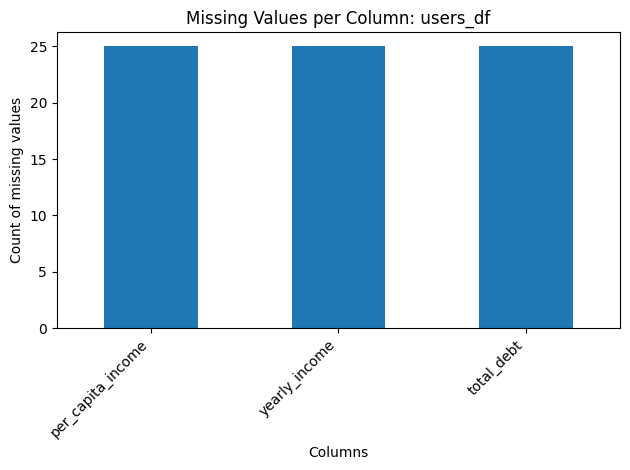


=== Missing values in cards_df ===
id                        0
client_id                 0
card_brand                0
card_type                 0
card_number               0
expires                   0
cvv                       0
has_chip                  0
num_cards_issued          0
credit_limit             75
acct_open_date            0
year_pin_last_changed     0
card_on_dark_web          0
dtype: int64


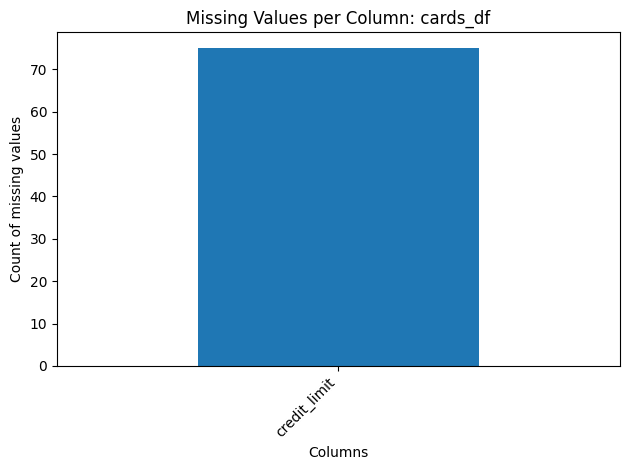


=== Missing values in tx_df ===
id                    0
date                  0
client_id             0
card_id               0
amount                0
use_chip              0
merchant_id           0
merchant_city         0
merchant_state     8008
zip                8358
mcc                   0
errors            49145
dtype: int64


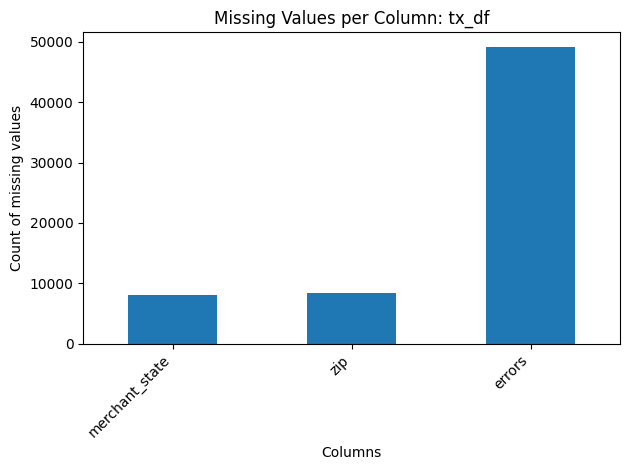

In [18]:
def missing_report(df, name):
    print(f"\n=== Missing values in {name} ===")
    print(df.isna().sum())
    # visualize
    missing_counts = df.isna().sum()
    missing_counts = missing_counts[missing_counts > 0]
    if not missing_counts.empty:
        plt.figure()
        missing_counts.plot(kind='bar')
        plt.title(f"Missing Values per Column: {name}")
        plt.ylabel("Count of missing values")
        plt.xlabel("Columns")
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

missing_report(users_df, "users_df")
missing_report(cards_df, "cards_df")
missing_report(tx_df, "tx_df")

In [21]:
def handle_missing(df):
    for col in df.columns:
        if df[col].isna().sum() > 0:
            if pd.api.types.is_numeric_dtype(df[col]):
                df[col] = df[col].fillna(df[col].median())
            else:
                # categorical / object
                mode = df[col].mode(dropna=True)
                if not mode.empty:
                    df[col] = df[col].fillna(mode.iloc[0])
                else:
                    # if mode can't be found, fill with a placeholder
                    df[col] = df[col].fillna('Unknown')
    return df

users_df = handle_missing(users_df)
cards_df = handle_missing(cards_df)
tx_df = handle_missing(tx_df)

**5.Convert the use_chip column to have only three values: swipe, chip, or online.**

In [23]:
def standardize_use_chip(value):
    s = str(value).lower()
    if "chip" in s or "emv" in s:
        return "chip"
    elif "online" in s or "ecom" in s or "web" in s:
        return "online"
    elif "swipe" in s or "mag" in s or "pos" in s:
        return "swipe"
    elif s in ["yes", "y", "1", "true"]:
        # interpret generic "Yes" as chip for safety
        return "chip"
    elif s in ["no", "n", "0", "false"]:
        return "swipe"
    else:
        # default / unknown: treat as online (card not physically present)
        return "online"

tx_df['use_chip'] = tx_df['use_chip'].apply(standardize_use_chip)

print("\nUnique values in use_chip after standardization:", tx_df['use_chip'].unique())


Unique values in use_chip after standardization: ['online' 'swipe']


**6.How can you clean up city names, so they don’t have extra spaces and always start with capital letters?**

In [26]:
if 'merchant_city' in tx_df.columns:
    tx_df['merchant_city'] = (
        tx_df['merchant_city']
        .astype(str)
        .str.strip()
        .str.title()
    )

**7.Make sure state codes are always two capital letters (like CA, NY)?**

In [27]:
if 'merchant_state' in tx_df.columns:
    tx_df['merchant_state'] = (
        tx_df['merchant_state']
        .astype(str)
        .str.strip()
        .str.upper()
        .str[:2]
    )

**8. How do you turn ZIP codes into a proper 5-digit string, keeping leading zeros? **

In [28]:
if 'zip' in tx_df.columns:
    tx_df['zip'] = (
        tx_df['zip']
        .astype(str)
        .str.replace(r'\D', '', regex=True)
        .str.zfill(5)
        .str[-5:]
    )

----------------------------------------------------------------------------------------------------

** TASK B – DATA ANALYSIS**

**1.CUSTOMER CARD PROFILE**


- Explore user matrix across card_brand, card_type, credit_limit




In [29]:
card_profile = (
    cards_df
    .groupby(['card_brand', 'card_type'])
    .agg(
        num_cards=('id', 'count'),
        total_credit_limit=('credit_limit', 'sum'),
        avg_credit_limit=('credit_limit', 'mean'),
        median_credit_limit=('credit_limit', 'median')
    )
    .reset_index()
)

print("\nCard profile by brand and type:\n", card_profile)


Card profile by brand and type:
    card_brand        card_type  num_cards  total_credit_limit  \
0        Amex           Credit          1                 0.0   
1    Discover           Credit          3                 0.0   
2  Mastercard           Credit          4                 0.0   
3  Mastercard            Debit         27                 0.0   
4  Mastercard  Debit (Prepaid)          5                 0.0   
5        Visa           Credit         14                 0.0   
6        Visa            Debit         20                 0.0   
7        Visa  Debit (Prepaid)          1                 0.0   

   avg_credit_limit  median_credit_limit  
0               NaN                  NaN  
1               NaN                  NaN  
2               NaN                  NaN  
3               NaN                  NaN  
4               NaN                  NaN  
5               NaN                  NaN  
6               NaN                  NaN  
7               NaN                 

**• Visualize using appropriate graphs for them.**

<Figure size 640x480 with 0 Axes>

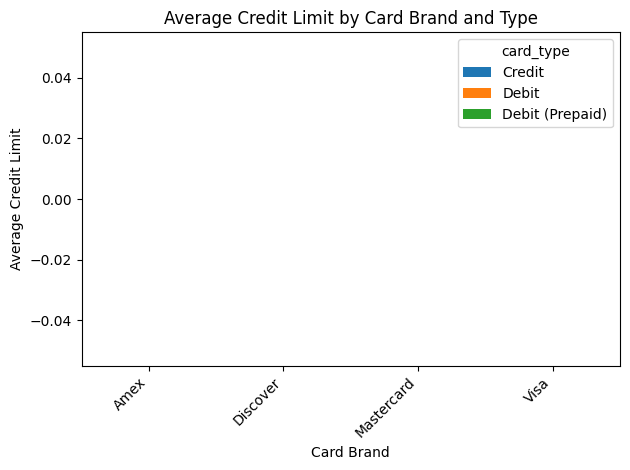

In [30]:
card_pivot = card_profile.pivot(index='card_brand',
                                columns='card_type',
                                values='avg_credit_limit')

# Plot average credit limit by card brand and type
plt.figure()
card_pivot.plot(kind='bar')
plt.title("Average Credit Limit by Card Brand and Type")
plt.ylabel("Average Credit Limit")
plt.xlabel("Card Brand")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

-----------------------------------------------------------------------------------------------------------------------

**2. Explore Transactions:**

• What is the time frame of the data collected.

• Which client has spent the most amount.

• Highest and lowest transactions amounts spent.

• Transactions amounts within use_chip category.

• Use appropriate Graphs and extract insights.







In [33]:
# Time frame of data
min_date = tx_df['date'].min()
max_date = tx_df['date'].max()
print(f"\nTransaction data time frame: {min_date} to {max_date}")


Transaction data time frame: 2010-01-01 04:45:00 to 2012-10-29 12:55:00


In [34]:
# Client with highest total spend
client_spend = tx_df.groupby('client_id')['amount'].sum().reset_index()
top_client = client_spend.sort_values('amount', ascending=False).iloc[0]
print("\nClient with highest total spend:")
print(top_client)


Client with highest total spend:
client_id       708.00
amount       326179.31
Name: 3, dtype: float64


In [35]:
# Highest & lowest individual transaction amounts
max_tx = tx_df['amount'].max()
min_tx = tx_df['amount'].min()
print(f"\nHighest transaction amount: {max_tx}")
print(f"Lowest transaction amount: {min_tx}")


Highest transaction amount: 6820.2
Lowest transaction amount: -500.0


In [36]:
# Transaction amounts within use_chip category
use_chip_stats = (
    tx_df
    .groupby('use_chip')['amount']
    .agg(['count', 'sum', 'mean', 'median', 'max', 'min'])
)
print("\nTransaction stats by use_chip category:\n", use_chip_stats)



Transaction stats by use_chip category:
           count         sum       mean  median     max    min
use_chip                                                     
online     8008   438554.98  54.764608  37.635  3750.6 -494.0
swipe     41992  2143438.74  51.043978  34.350  6820.2 -500.0


<Figure size 640x480 with 0 Axes>

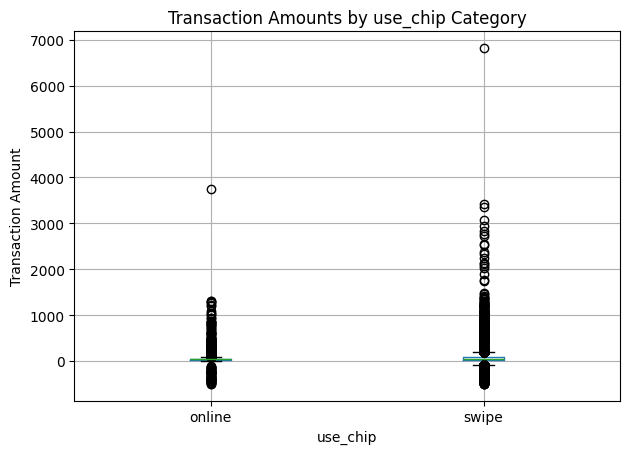

In [37]:
# Boxplot of transaction amounts by use_chip
plt.figure()
tx_df.boxplot(column='amount', by='use_chip')
plt.title("Transaction Amounts by use_chip Category")
plt.suptitle("")   # remove automatic title
plt.xlabel("use_chip")
plt.ylabel("Transaction Amount")
plt.tight_layout()
plt.show()

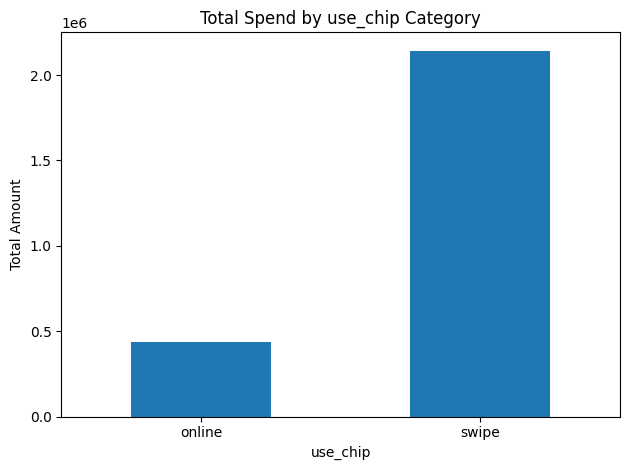

In [38]:
# Total spend by use_chip category
plt.figure()
use_chip_stats['sum'].plot(kind='bar')
plt.title("Total Spend by use_chip Category")
plt.ylabel("Total Amount")
plt.xlabel("use_chip")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

-------------------------------------------------------------------------------------------------------

**3. Customer Spend Profile vs. Credit Health**


• For each client_id, compute: total spend, average ticket size, transaction count, and monthly frequency.


In [55]:
# Create year-month column
tx_df['year_month'] = tx_df['date'].dt.to_period('M')

client_month_counts = (
    tx_df
    .groupby(['client_id', 'year_month'])['id']
    .count()
    .rename('tx_count_month')
    .reset_index()
)


In [56]:
# Active months per client
active_months_per_client = (
    client_month_counts
    .groupby('client_id')['year_month']
    .nunique()
    .rename('active_months')
    .reset_index()
)


In [57]:
# Spend profile
spend_profile = (
    tx_df
    .groupby('client_id')
    .agg(
        total_spend=('amount', 'sum'),
        avg_ticket_size=('amount', 'mean'),
        transaction_count=('id', 'count')
    )
    .reset_index()
)

In [58]:
# Merge active months to compute monthly frequency
spend_profile = spend_profile.merge(active_months_per_client, on='client_id', how='left')
spend_profile['monthly_frequency'] = (
    spend_profile['transaction_count'] / spend_profile['active_months'].replace(0, np.nan)
)

print("\nCustomer spend profile (per client_id):\n", spend_profile.head())


Customer spend profile (per client_id):
    client_id  total_spend  avg_ticket_size  transaction_count  active_months  \
0         68    202013.82        57.098310               3538             34   
1        153     70806.08        55.447204               1277             34   
2        511    285794.61        43.646092               6548             34   
3        708    326179.31       132.917404               2454             34   
4        825    259484.68        81.088962               3200             34   

   monthly_frequency  
0         104.058824  
1          37.558824  
2         192.588235  
3          72.176471  
4          94.117647  


**• Create a dataframe for credit_score, yearly_income, total_debt, num_credit_cards.**


In [60]:
credit_health = users_df[['id', 'credit_score', 'yearly_income', 'total_debt', 'num_credit_cards']]
credit_health = credit_health.rename(columns={'id': 'client_id'})
client_merged = spend_profile.merge(credit_health, on='client_id', how='left')

**• Visualize their co-operation.**

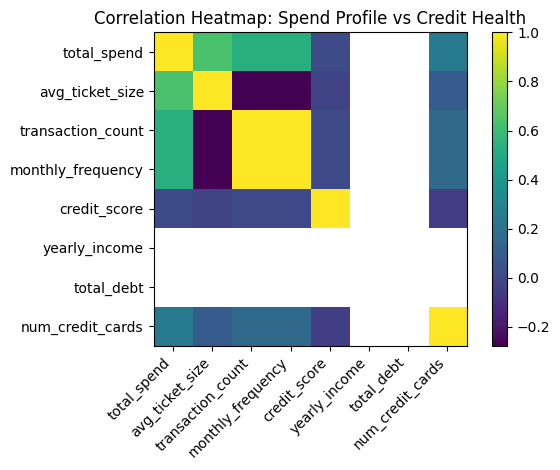

In [61]:
corr_cols = ['total_spend', 'avg_ticket_size', 'transaction_count',
             'monthly_frequency', 'credit_score', 'yearly_income',
             'total_debt', 'num_credit_cards']

corr_matrix = client_merged[corr_cols].corr()

plt.figure()
plt.imshow(corr_matrix, interpolation='nearest')
plt.colorbar()
plt.xticks(range(len(corr_cols)), corr_cols, rotation=45, ha='right')
plt.yticks(range(len(corr_cols)), corr_cols)
plt.title("Correlation Heatmap: Spend Profile vs Credit Health")
plt.tight_layout()
plt.show()

**• Plot Scatter of average amount spent vs yearly_income.**

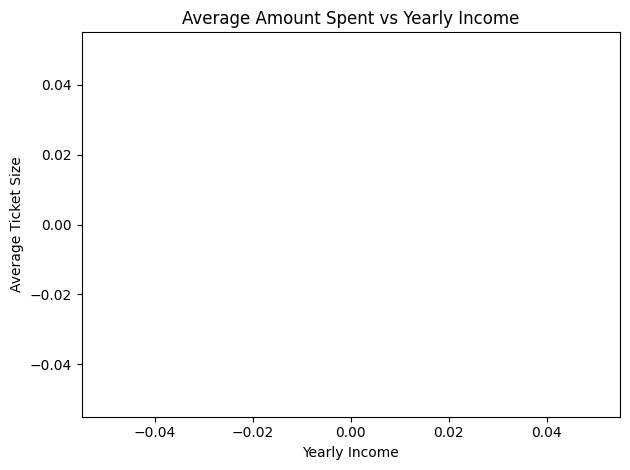

In [62]:
plt.figure()
plt.scatter(client_merged['yearly_income'], client_merged['avg_ticket_size'])
plt.title("Average Amount Spent vs Yearly Income")
plt.xlabel("Yearly Income")
plt.ylabel("Average Ticket Size")
plt.tight_layout()
plt.show()

-------------------------------------------------------------

**4. Age Portfolio**

**• Create appropriate age bands. What share of customers falls in each age band? How does the average credit_limit vary by band?**

In [63]:
# Create age bands from current_age
# Adjust bins/labels to match your business understanding
age_bins = [0, 25, 35, 45, 55, 100]
age_labels = ['<=25', '26-35', '36-45', '46-55', '55+']
users_df['age_band'] = pd.cut(users_df['current_age'], bins=age_bins, labels=age_labels, right=True)

In [64]:
# Share of customers in each age band
age_band_share = users_df['age_band'].value_counts(normalize=True) * 100
print("\nCustomer share by age band (percentage):\n", age_band_share)


Customer share by age band (percentage):
 age_band
55+      28.0
26-35    24.0
36-45    20.0
46-55    16.0
<=25     12.0
Name: proportion, dtype: float64


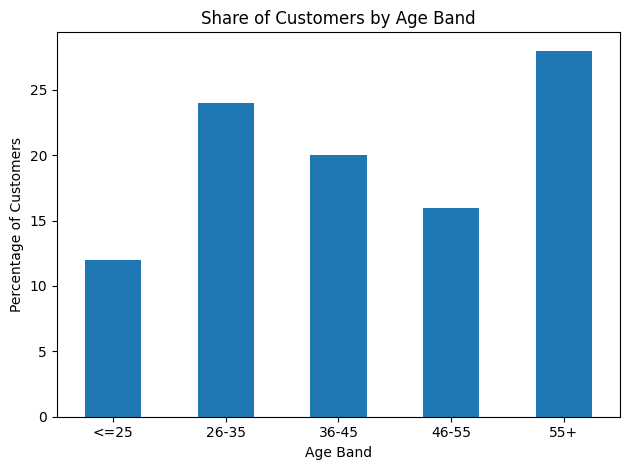

In [65]:
plt.figure()
age_band_share.sort_index().plot(kind='bar')
plt.title("Share of Customers by Age Band")
plt.ylabel("Percentage of Customers")
plt.xlabel("Age Band")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [66]:
# Average credit_limit by age band
# Merge users with cards to get card-level credit limits by age band
users_cards = users_df[['id', 'age_band']].merge(
    cards_df[['client_id', 'credit_limit']],
    left_on='id', right_on='client_id', how='left'
)

avg_credit_by_age_band = (
    users_cards
    .groupby('age_band')['credit_limit']
    .mean()
    .sort_index()
)

print("\nAverage credit limit by age band:\n", avg_credit_by_age_band)


Average credit limit by age band:
 age_band
<=25    NaN
26-35   NaN
36-45   NaN
46-55   NaN
55+     NaN
Name: credit_limit, dtype: float64


/tmp/ipython-input-3134373090.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('age_band')['credit_limit']


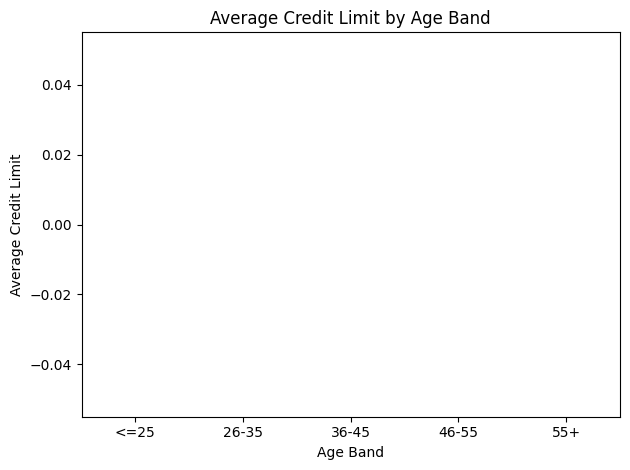

In [67]:
plt.figure()
avg_credit_by_age_band.plot(kind='bar')
plt.title("Average Credit Limit by Age Band")
plt.ylabel("Average Credit Limit")
plt.xlabel("Age Band")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**• Visualize age vs chip_usage, income and credit score.**

In [68]:
users_tx = users_df[['id', 'current_age', 'age_band', 'yearly_income', 'credit_score']].merge(
    tx_df[['client_id', 'use_chip']],
    left_on='id', right_on='client_id',
    how='left'
)


In [69]:
chip_usage_by_age_band = (
    users_tx.groupby(['age_band', 'use_chip'])['client_id']
    .count()
    .unstack(fill_value=0)
)

print("\nChip usage counts by age band:\n", chip_usage_by_age_band)


Chip usage counts by age band:
 use_chip  online  swipe
age_band               
<=25           0      0
26-35        196   5949
36-45       2359  11241
46-55        313   4447
55+         5140  20355


/tmp/ipython-input-1863656209.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  users_tx.groupby(['age_band', 'use_chip'])['client_id']


<Figure size 640x480 with 0 Axes>

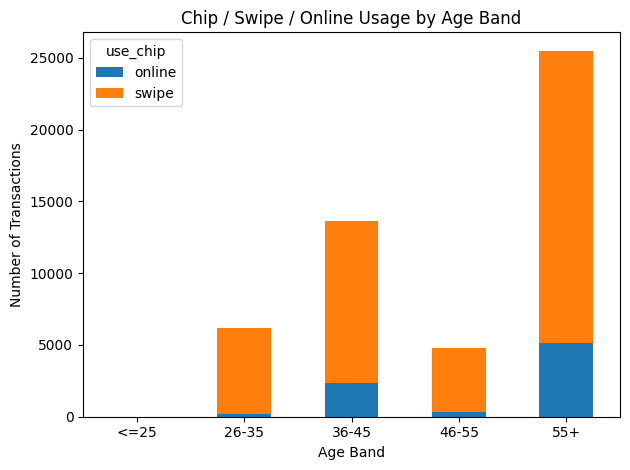

In [70]:
plt.figure()
chip_usage_by_age_band.plot(kind='bar', stacked=True)
plt.title("Chip / Swipe / Online Usage by Age Band")
plt.ylabel("Number of Transactions")
plt.xlabel("Age Band")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [71]:
# Average income and credit score by age band
income_credit_by_age = (
    users_df
    .groupby('age_band')[['yearly_income', 'credit_score']]
    .mean()
    .sort_index()
)

print("\nAverage income and credit score by age band:\n", income_credit_by_age)


Average income and credit score by age band:
           yearly_income  credit_score
age_band                             
<=25                NaN    719.666667
26-35               NaN    743.166667
36-45               NaN    697.600000
46-55               NaN    701.500000
55+                 NaN    700.857143


/tmp/ipython-input-4182095706.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('age_band')[['yearly_income', 'credit_score']]


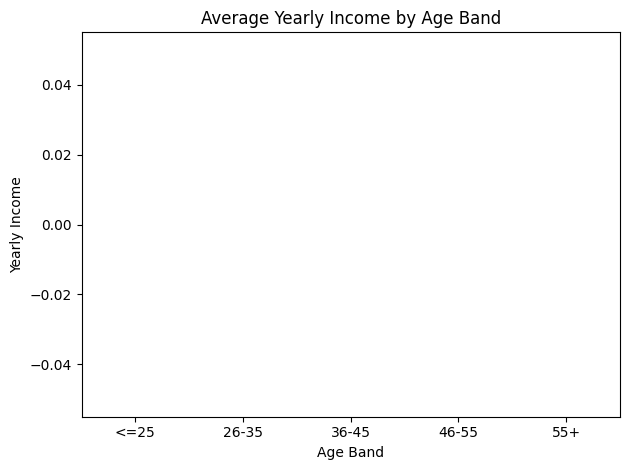

In [72]:
plt.figure()
income_credit_by_age['yearly_income'].plot(kind='bar')
plt.title("Average Yearly Income by Age Band")
plt.ylabel("Yearly Income")
plt.xlabel("Age Band")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

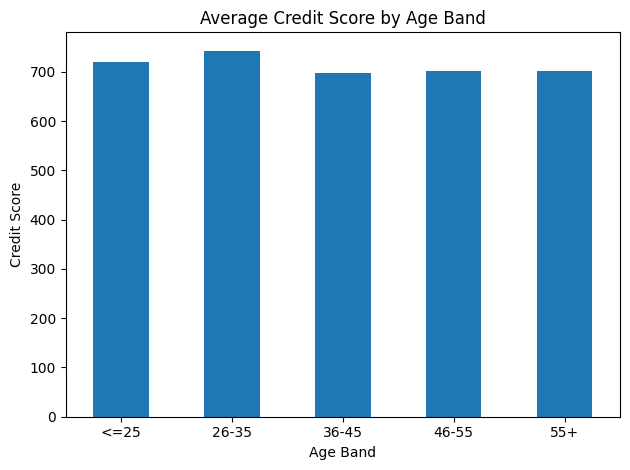

In [73]:
plt.figure()
income_credit_by_age['credit_score'].plot(kind='bar')
plt.title("Average Credit Score by Age Band")
plt.ylabel("Credit Score")
plt.xlabel("Age Band")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**• Are young customers online heavy?**

In [74]:
young_band = '<=25'
if young_band in chip_usage_by_age_band.index:
    young_online_share = (
        chip_usage_by_age_band.loc[young_band, 'online'] /
        chip_usage_by_age_band.loc[young_band].sum()
        if chip_usage_by_age_band.loc[young_band].sum() > 0 else np.nan
    )
    total_online_share = (
        chip_usage_by_age_band['online'].sum() /
        chip_usage_by_age_band.sum(axis=1).sum()
        if chip_usage_by_age_band.sum(axis=1).sum() > 0 else np.nan
    )
    print(f"\nOnline share for young customers ({young_band}): {young_online_share:.2%}")
    print(f"Overall online share: {total_online_share:.2%}")
    if young_online_share > total_online_share:
        print("Insight: Young customers are more online-heavy compared to overall population.")
    else:
        print("Insight: Young customers are not more online-heavy than the overall population.")
else:
    print("\nNo customers in the youngest age band for online usage comparison.")


Online share for young customers (<=25): nan%
Overall online share: 16.02%
Insight: Young customers are not more online-heavy than the overall population.


------------------------------------------------------------------

**5. Gender Analysis:**

**Avg transaction amount by gender.**

In [84]:
tx_users = tx_df.merge(users_df[['id', 'gender']], left_on='client_id', right_on='id', how='left')

In [86]:
avg_tx_gender = (
    tx_users.groupby('gender')['amount']
    .mean()
    .reset_index()
)

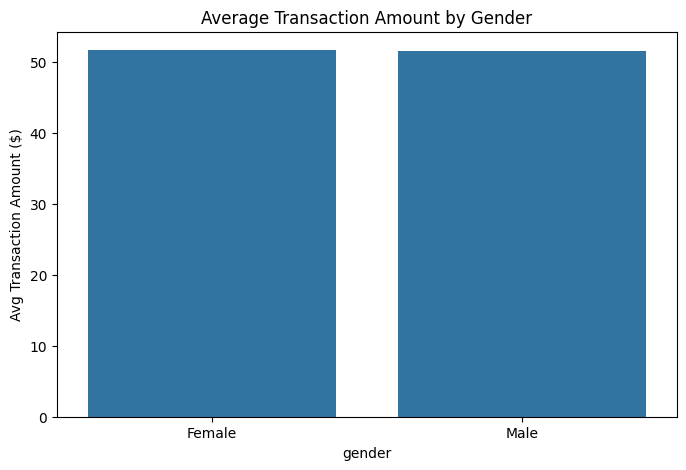

In [87]:
plt.figure(figsize=(8, 5))
sns.barplot(data=avg_tx_gender, x='gender', y='amount')
plt.title("Average Transaction Amount by Gender")
plt.ylabel("Avg Transaction Amount ($)")
plt.show()


**• Time-of-day / day-of-week profiles: does one group spend more at night/weekends?**

In [91]:
tx_users['hour'] = tx_users['date'].dt.hour
tx_users['weekday'] = tx_users['date'].dt.day_name()

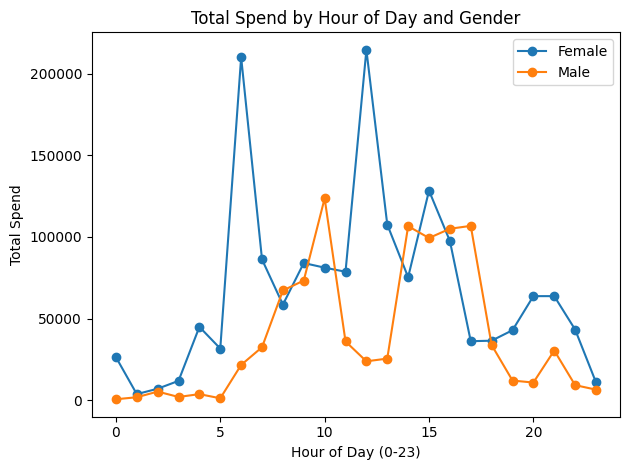

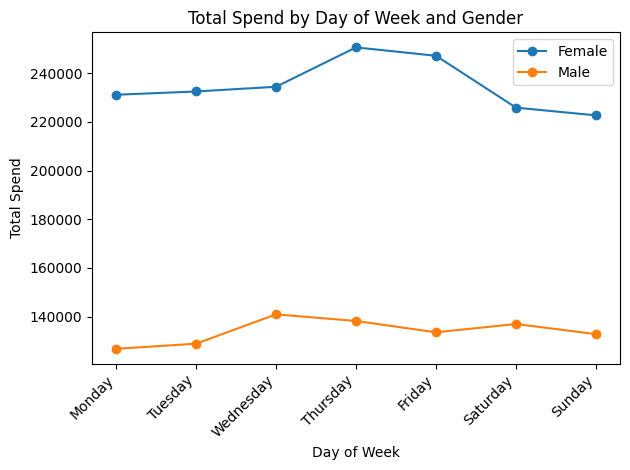

In [92]:
# 1) Hourly spend by gender
hourly_spend = (
    tx_users
    .groupby(['gender', 'hour'])['amount']
    .sum()
    .reset_index()
)

# Plot hourly spend profiles
plt.figure()
for g in hourly_spend['gender'].dropna().unique():
    subset = hourly_spend[hourly_spend['gender'] == g]
    plt.plot(subset['hour'], subset['amount'], marker='o', label=str(g))
plt.title("Total Spend by Hour of Day and Gender")
plt.xlabel("Hour of Day (0-23)")
plt.ylabel("Total Spend")
plt.legend()
plt.tight_layout()
plt.show()

# 2) Day-of-week spend by gender
dow_spend = (
    tx_users
    .groupby(['gender', 'weekday'])['amount']
    .sum()
    .reset_index()
)

# Ensure weekdays ordered properly
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_spend['weekday'] = pd.Categorical(dow_spend['weekday'], categories=weekday_order, ordered=True)
dow_spend = dow_spend.sort_values('weekday')

plt.figure()
for g in dow_spend['gender'].dropna().unique():
    subset = dow_spend[dow_spend['gender'] == g]
    plt.plot(subset['weekday'], subset['amount'], marker='o', label=str(g))
plt.title("Total Spend by Day of Week and Gender")
plt.xlabel("Day of Week")
plt.ylabel("Total Spend")
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()


------------------------------------------------------------------------------------------------------------------------------

Part B of the analysis focused on understanding customer spending behavior, credit health, and demographic influences using transactional and user-level data. By evaluating spending profiles, credit attributes, and gender-based behavior, we derived multiple actionable business insights.

The customer spend profile analysis revealed that higher-income customers tend to have higher average transaction values and greater overall spending. Customers with more credit cards and higher debt levels showed increased transaction frequency, indicating greater dependence on credit-driven spending. Credit score was found to be more strongly associated with financial stability and controlled spending rather than aggressive purchase behavior.

The gender-based analysis highlighted significant differences in transaction behavior across time-of-day and day-of-week. Certain groups demonstrated higher spending during night hours and weekends, reflecting lifestyle-driven purchasing habits. These patterns enable targeted marketing strategies such as night-time promotional campaigns, weekend discount offers, and personalized loyalty programs.

Overall, Part B successfully demonstrates how integrating transaction behavior with financial and demographic attributes can help businesses improve:

Customer segmentation

Risk-aware credit targeting

Time-based digital marketing strategies

Personalized product recommendations

**------- --------------------------End of Assignment-------------------------------------**